In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path
from collections import Counter
import hashlib

In [2]:
# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
dataset_path = r"D:\Project Jupyter\Dataset_baru"

In [4]:
# Inisialisasi list penampung
image_paths = []
labels = []
extensions = []
splits = []

# Daftar folder split
split_folders = ['train', 'val', 'test']

# Loop tiap split (train/val/test)
for split_name in split_folders:
    split_path = os.path.join(dataset_path, split_name)
    
    # Ambil daftar kelas dalam split (edible/poisonous)
    classes = sorted([d for d in os.listdir(split_path) if os.path.isdir(os.path.join(split_path, d))])
    
    for class_name in classes:
        class_path = os.path.join(split_path, class_name)
        
        # Ambil file gambar dengan ekstensi tertentu
        images = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        
        for img in images:
            image_paths.append(os.path.join(class_path, img))
            labels.append(class_name)
            splits.append(split_name)
            extensions.append(img.split('.')[-1].lower())


In [5]:
df = pd.DataFrame({
    'image_path': image_paths,
    'label': labels,
    'extension': extensions,
    'split': splits
})


In [6]:
all_files = []
for root, dirs, files in os.walk(split_path):
    for file in files:
        all_files.append(file)

# Hitung duplikat
duplicates = [item for item, count in Counter(all_files).items() if count > 1]

print("Jumlah file duplikat berdasarkan nama:", len(duplicates))
print("Daftar file duplikat:", duplicates)

Jumlah file duplikat berdasarkan nama: 0
Daftar file duplikat: []


In [7]:
hashes = {}
duplicates = []

def hash_file(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

for root, dirs, files in os.walk(split_path):
    for file in files:
        file_path = os.path.join(root, file)
        file_hash = hash_file(file_path)

        if file_hash in hashes:
            duplicates.append((file_path, hashes[file_hash]))
        else:
            hashes[file_hash] = file_path

print("Jumlah gambar duplikat berdasarkan konten:", len(duplicates))
for dup in duplicates:
    print("Duplikat:", dup)

Jumlah gambar duplikat berdasarkan konten: 0


In [8]:
import os
import cv2
import pytesseract
from PIL import Image

pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

text_images = []

for root, dirs, files in os.walk(split_path):
    for f in files:
        if f.lower().endswith((".jpg", ".png", ".jpeg")):
            path = os.path.join(root, f)

            img = cv2.imread(path)
            if img is None:
                continue

            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            text = pytesseract.image_to_string(gray)

            if len(text.strip()) > 10:   # threshold teks
                text_images.append(path)
                print("TEXT IMAGE:", path)

print("\nTOTAL GAMBAR MENGANDUNG TEKS:", len(text_images))



TOTAL GAMBAR MENGANDUNG TEKS: 0


In [9]:
# Hitung jenis file
ext_counts = df['extension'].value_counts()

print(f"Dataset berhasil dimuat!")
print(f"   Total gambar: {len(df)}")
print(f"   Jumlah kelas: {len(classes)}")
print(f"   Nama kelas: {classes}")
print(f"   Split : {list(df['split'].unique())}\n")
print(f"\n   Jenis file gambar:")
for ext, count in ext_counts.items():
    percentage = (count / len(df)) * 100
    print(f"      {ext:6} : {count:4} gambar ({percentage:.1f}%)")

Dataset berhasil dimuat!
   Total gambar: 2770
   Jumlah kelas: 2
   Nama kelas: ['edible', 'poisonous']
   Split : ['train', 'val', 'test']


   Jenis file gambar:
      jpg    : 2616 gambar (94.4%)
      png    :  154 gambar (5.6%)


In [10]:
# 2. EDA - DISTRIBUSI DATA

# Hitung jumlah per kelas
class_counts = df['label'].value_counts().sort_index()

print("\nJumlah Data per Kelas:")
print("-" * 40)
for class_name, count in class_counts.items():
    percentage = (count / len(df)) * 100
    print(f"   {class_name:15} : {count:4} gambar ({percentage:.1f}%)")
print("-" * 40)
print(f"   {'TOTAL':15} : {len(df):4} gambar")


Jumlah Data per Kelas:
----------------------------------------
   edible          : 1470 gambar (53.1%)
   poisonous       : 1300 gambar (46.9%)
----------------------------------------
   TOTAL           : 2770 gambar


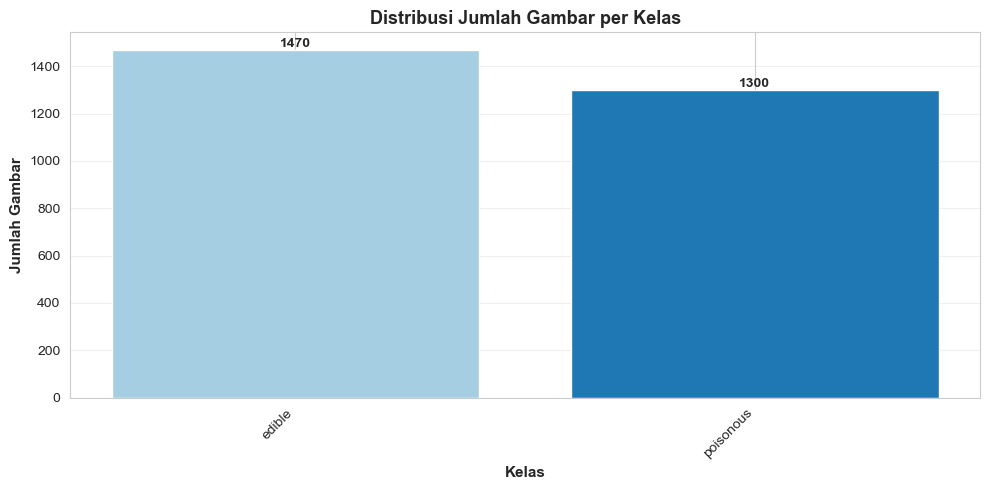

In [11]:
# Visualisasi distribusi - Diagram Batang Saja
plt.figure(figsize=(10, 5))

# Warna
colors = sns.color_palette("Paired", len(class_counts))

# Bar chart
bars = plt.bar(range(len(class_counts)), class_counts.values, color=colors)

plt.xticks(range(len(class_counts)), class_counts.index, rotation=45, ha='right')
plt.ylabel('Jumlah Gambar', fontsize=11, fontweight='bold')
plt.xlabel('Kelas', fontsize=11, fontweight='bold')
plt.title('Distribusi Jumlah Gambar per Kelas', fontsize=13, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# Tambah label di atas bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


In [12]:
# 3. EDA - PROPERTI GAMBAR

# analisis gambar
image_size = min(2770, len(df))
image_df = df.sample(n=image_size, random_state=42)

widths = []
heights = []
color_modes = []
extensions = []
sizes_kb = []

for img_path in image_df['image_path']:
    try:
        img = Image.open(img_path)
        widths.append(img.size[0])
        heights.append(img.size[1])
        color_modes.append(img.mode)
        extensions.append(os.path.splitext(img_path)[1].lower())
        sizes_kb.append(os.path.getsize(img_path) / 1024)
    except:
        continue

In [13]:
# Ringkasan properti
print(f"\nUkuran Gambar (dari {len(widths)} gambar):")
print(f"   Width  : Min={min(widths)}px, Max={max(widths)}px, Mean={np.mean(widths):.0f}px")
print(f"   Height : Min={min(heights)}px, Max={max(heights)}px, Mean={np.mean(heights):.0f}px")

print(f"\nTipe File Gambar:")
ext_counts = pd.Series(extensions).value_counts()
for ext, count in ext_counts.items():
    print(f"   {ext:10} : {count} gambar")

print(f"\nColor Mode:")
mode_counts = pd.Series(color_modes).value_counts()
for mode, count in mode_counts.items():
    print(f"   {mode:10} : {count} gambar")

print(f"\nUkuran File:")
print(f"   Min  : {min(sizes_kb):.1f} KB")
print(f"   Max  : {max(sizes_kb):.1f} KB")
print(f"   Mean : {np.mean(sizes_kb):.1f} KB")


Ukuran Gambar (dari 2770 gambar):
   Width  : Min=260px, Max=9312px, Mean=1037px
   Height : Min=260px, Max=6466px, Mean=863px

Tipe File Gambar:
   .jpg       : 2616 gambar
   .png       : 154 gambar

Color Mode:
   RGB        : 2667 gambar
   RGBA       : 67 gambar
   P          : 36 gambar

Ukuran File:
   Min  : 7.2 KB
   Max  : 13809.4 KB
   Mean : 435.1 KB



Aspect Ratio (W/H):
   Min  : 0.44
   Max  : 4.00
   Mean : 1.27


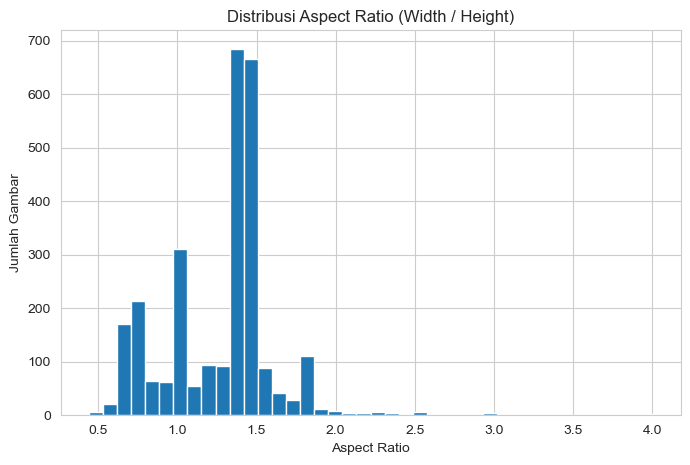

In [14]:
# ===== TAMBAHAN ANALISIS ASPECT RATIO =====

aspect_ratios = []
for w, h in zip(widths, heights):
    if h != 0:
        aspect_ratios.append(w / h)

print(f"\nAspect Ratio (W/H):")
print(f"   Min  : {min(aspect_ratios):.2f}")
print(f"   Max  : {max(aspect_ratios):.2f}")
print(f"   Mean : {np.mean(aspect_ratios):.2f}")

plt.figure(figsize=(8,5))
plt.hist(aspect_ratios, bins=40)
plt.title("Distribusi Aspect Ratio (Width / Height)")
plt.xlabel("Aspect Ratio")
plt.ylabel("Jumlah Gambar")
plt.show()



Analisis Blur:
Min: 5.36
Max: 37664.79
Mean: 1307.45

Analisis Brightness:
Min: 29.3
Max: 245.5
Mean: 115.7


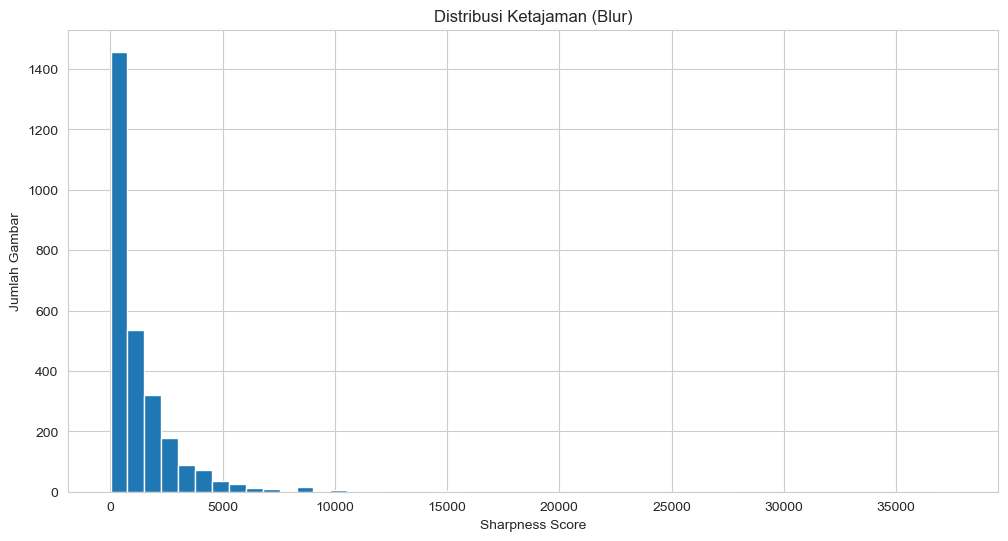

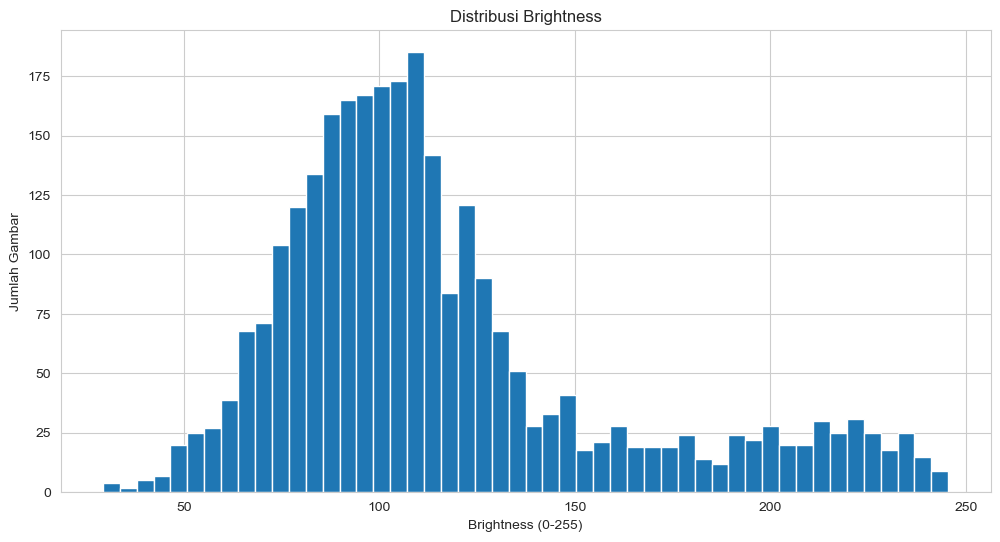

In [15]:
# 3B. BLUR & BRIGHTNESS
# =========================

blur_scores = []
brightness_scores = []

for img_path in image_df['image_path']:
    try:
        img = cv2.imread(img_path)
        if img is None:
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        blur = cv2.Laplacian(gray, cv2.CV_64F).var()
        blur_scores.append(blur)

        brightness = np.mean(gray)
        brightness_scores.append(brightness)

    except:
        continue

print("\nAnalisis Blur:")
print(f"Min: {np.min(blur_scores):.2f}")
print(f"Max: {np.max(blur_scores):.2f}")
print(f"Mean: {np.mean(blur_scores):.2f}")

print("\nAnalisis Brightness:")
print(f"Min: {np.min(brightness_scores):.1f}")
print(f"Max: {np.max(brightness_scores):.1f}")
print(f"Mean: {np.mean(brightness_scores):.1f}")

plt.figure()
plt.hist(blur_scores, bins=50)
plt.title("Distribusi Ketajaman (Blur)")
plt.xlabel("Sharpness Score")
plt.ylabel("Jumlah Gambar")
plt.show()

plt.figure()
plt.hist(brightness_scores, bins=50)
plt.title("Distribusi Brightness")
plt.xlabel("Brightness (0-255)")
plt.ylabel("Jumlah Gambar")
plt.show()



Sample Gambar per Kelas:


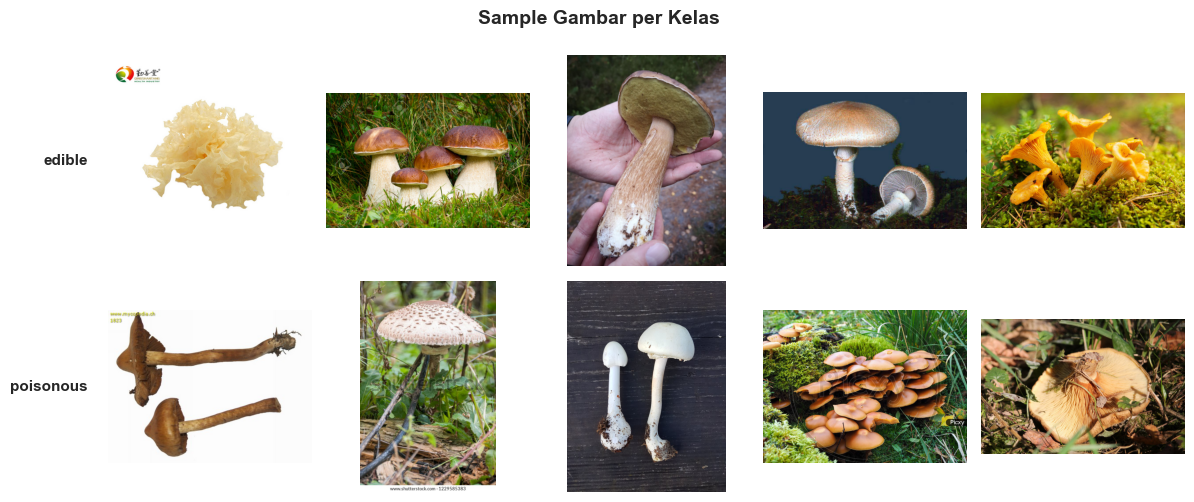

In [16]:
# 4. SAMPLE GAMBAR
print("\nSample Gambar per Kelas:")

n_samples = 5  # Jumlah sample per kelas
fig, axes = plt.subplots(len(classes), n_samples, figsize=(12, len(classes)*2.5))

for i, class_name in enumerate(classes):
    class_images = df[df['label'] == class_name].sample(n=n_samples, random_state=42)
    
    for j, (idx, row) in enumerate(class_images.iterrows()):
        img = Image.open(row['image_path'])
        
        if len(classes) == 1:
            ax = axes[j]
        else:
            ax = axes[i, j]
        
        ax.imshow(img)
        ax.axis('off')
        
        if j == 0:
            ax.text(-0.1, 0.5, class_name, transform=ax.transAxes,
                   fontsize=11, fontweight='bold', va='center', ha='right')

plt.suptitle('Sample Gambar per Kelas', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

In [36]:
print("\nDataset Summary:")
print(f"   - Total data: {len(df)} gambar")
print(f"   - Jumlah kelas: {len(classes)}")
print(f"   - Ukuran rata-rata: {np.mean(widths):.0f}x{np.mean(heights):.0f} pixels")
print(f"   - Tipe file: {', '.join(ext_counts.index.tolist())}")
print(f"   - Color mode: {', '.join(mode_counts.index.tolist())}")

# Cek imbalance
imbalance_ratio = class_counts.max() / class_counts.min()
if imbalance_ratio > 1.5:
    print(f"\nPerhatian: Dataset tidak seimbang (ratio: {imbalance_ratio:.2f}x)")
    print("   - Gunakan data augmentation")
else:
    print(f"\nDataset seimbang (ratio: {imbalance_ratio:.2f}x)")

print("\nRekomendasi untuk MobileNet:")
print("   - Input size: 224x224")
print("   - Preprocessing: Resize with padding + Normalisasi (0-1)")
print("   - Data split: 80% train, 10% val, 10% test")

print(f"\nDataset tersimpan dalam variabel: df")
print(f"Daftar kelas tersimpan dalam: classes")
print(f"Akses data: df['image_path'] dan df['label']")


Dataset Summary:
   - Total data: 2770 gambar
   - Jumlah kelas: 2
   - Ukuran rata-rata: 1037x863 pixels
   - Tipe file: .jpg, .png
   - Color mode: RGB, RGBA, P

Dataset seimbang (ratio: 1.13x)

Rekomendasi untuk MobileNet:
   - Input size: 224x224
   - Preprocessing: Resize with padding + Normalisasi (0-1)
   - Data split: 80% train, 10% val, 10% test

Dataset tersimpan dalam variabel: df
Daftar kelas tersimpan dalam: classes
Akses data: df['image_path'] dan df['label']
